In [2]:
import sqlite3
import seaborn as sns
import pandas as pd

conn = sqlite3.connect('../data/mental_health.sqlite')

df = pd.read_sql("""
    SELECT a.UserID, a.SurveyID, a.AnswerText, q.questiontext
    FROM Answer a
    JOIN Question q ON a.QuestionID = q.questionid
""", conn)

df_wide = df.pivot_table(
    index=['UserID', 'SurveyID'],
    columns='questiontext',
    values='AnswerText',
    aggfunc='first'
).reset_index()

threshold = 50
df_clean = df_wide.loc[:, df_wide.isnull().sum() / len(df_wide) * 100 < threshold]

cols_to_drop = ['UserID', 'If you live in the United States, which state or territory do you live in?',
                'What US state or territory do you work in?', 'What country do you live in?',
                'What country do you work in?']
df_clean = df_clean.drop(columns=cols_to_drop)

df_clean['What is your age?'] = pd.to_numeric(df_clean['What is your age?'], errors='coerce')
df_clean = df_clean[df_clean['What is your age?'].between(18, 80)]

def clean_gender(g):
    if pd.isna(g): return None
    g = str(g).strip().lower()
    if g in ['male', 'm', 'man', 'cis male', 'cis man', 'masculine', 'masculino', 'mail', 'malr', 'sex is male']:
        return 'Male'
    elif g in ['female', 'f', 'woman', 'cis female', 'cis woman', 'feminine', 'femail', 'femake', 'female (cis)']:
        return 'Female'
    else:
        return 'Other'

df_clean['What is your gender?'] = df_clean['What is your gender?'].apply(clean_gender)

df_model = df_clean.dropna()

target_col = 'Have you ever sought treatment for a mental health disorder from a mental health professional?'

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
target_col = 'Have you ever sought treatment for a mental health disorder from a mental health professional?'

X = df_model.drop(columns=[target_col])
y = df_model[target_col].astype(int)

print(X.shape)
print(y.value_counts())

(1428, 41)
Have you ever sought treatment for a mental health disorder from a mental health professional?
1    837
0    591
Name: count, dtype: int64


In [5]:
print(X.dtypes.value_counts())

object    39
int64      2
Name: count, dtype: int64


In [6]:
le = LabelEncoder()

X_encoded = X.copy()

for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print(X_encoded.dtypes.value_counts())
print(X_encoded.shape)

int64    41
Name: count, dtype: int64
(1428, 41)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(1142, 41)
(286, 41)


In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.77      0.90      0.83       121
           1       0.92      0.80      0.85       165

    accuracy                           0.84       286
   macro avg       0.84      0.85      0.84       286
weighted avg       0.85      0.84      0.84       286



c:\Users\Hasna\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
lr = LogisticRegression(max_iter=3000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.77      0.89      0.82       121
           1       0.91      0.80      0.85       165

    accuracy                           0.84       286
   macro avg       0.84      0.85      0.84       286
weighted avg       0.85      0.84      0.84       286



In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.80      0.88      0.83       121
           1       0.90      0.84      0.87       165

    accuracy                           0.85       286
   macro avg       0.85      0.86      0.85       286
weighted avg       0.86      0.85      0.85       286



C:\Users\Hasna\AppData\Local\Temp\ipykernel_15600\1351871426.py:13: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


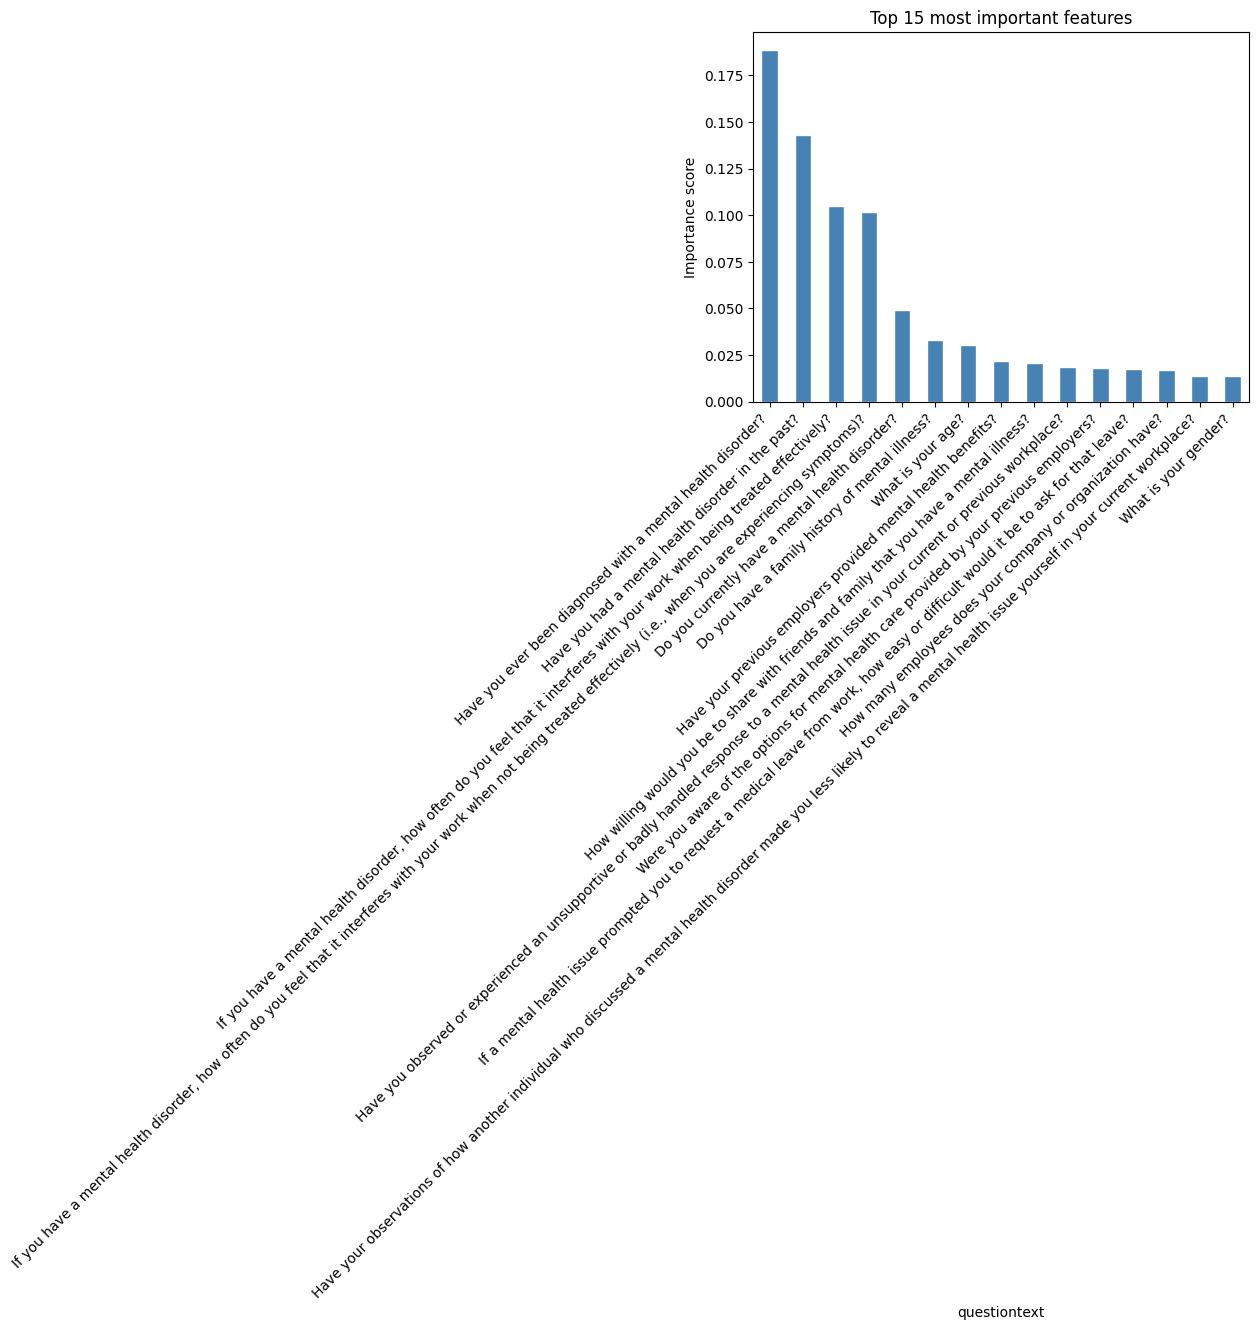

questiontext
Have you ever been diagnosed with a mental health disorder?                                                                                                                     0.188885
Have you had a mental health disorder in the past?                                                                                                                              0.143117
If you have a mental health disorder, how often do you feel that it interferes with your work when being treated effectively?                                                   0.104933
If you have a mental health disorder, how often do you feel that it interferes with your work when not being treated effectively (i.e., when you are experiencing symptoms)?    0.101753
Do you currently have a mental health disorder?                                                                                                                                 0.049273
Do you have a family history of mental illness?               

In [11]:
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

# Plot top 15
feature_importance.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 most important features')
plt.ylabel('Importance score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(feature_importance.head(10))

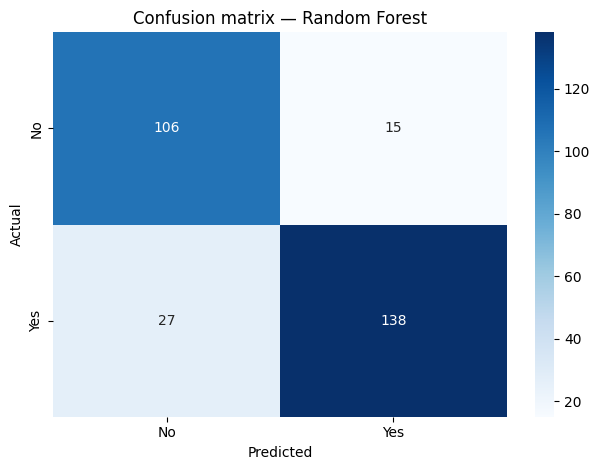

In [12]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [14]:
import os
os.makedirs('../model', exist_ok=True)

In [15]:
import pickle

with open('../model/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../model/label_encoders.pkl', 'wb') as f:
    pickle.dump(X_encoded.columns.tolist(), f)

print("Model saved successfully")

Model saved successfully


In [16]:
print(X_encoded.columns.tolist())

['SurveyID', 'Are you self-employed?', 'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?', 'Did your previous employers provide resources to learn more about mental health disorders and how to seek help?', 'Do you believe your productivity is ever affected by a mental health issue?', 'Do you currently have a mental health disorder?', 'Do you feel that your employer takes mental health as seriously as physical health?', 'Do you have a family history of mental illness?', 'Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?', 'Do you have previous employers?', 'Do you know local or online resources to seek help for a mental health issue?', 'Do you know the options for mental health care available under your employer-provided health coverage?', 'Do you think that discussing a physical health issue with your employer would have negative conseque

In [17]:
import pickle
from sklearn.preprocessing import LabelEncoder

encoders = {}
X_encoded2 = X.copy()

for col in X_encoded2.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_encoded2[col] = le.fit_transform(X_encoded2[col].astype(str))
    encoders[col] = le

with open('../model/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Encoders saved")
print(encoders['Do you have a family history of mental illness?'].classes_)

Encoders saved
["I don't know" 'No' 'Yes']
